In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np
from itertools import product
from itertools import combinations
import time


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/sysad/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sysad/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/sysad/.local/lib/python3.10/site-packag

AttributeError: _ARRAY_API not found

(CVXPY) Dec 20 11:11:19 AM: Encountered unexpected exception importing solver ECOS:
ImportError('numpy.core.multiarray failed to import')

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/sysad/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sysad/.local/lib/python3.10/site-pack

AttributeError: _ARRAY_API not found

(CVXPY) Dec 20 11:11:19 AM: Encountered unexpected exception importing solver ECOS_BB:
ImportError('numpy.core.multiarray failed to import')


/tmp/ipykernel_23283/4005306379.py:3: RuntimeWarning: invalid value encountered in power
  "concave": lambda x: np.cos(np.pi * x / 10)**0.3,


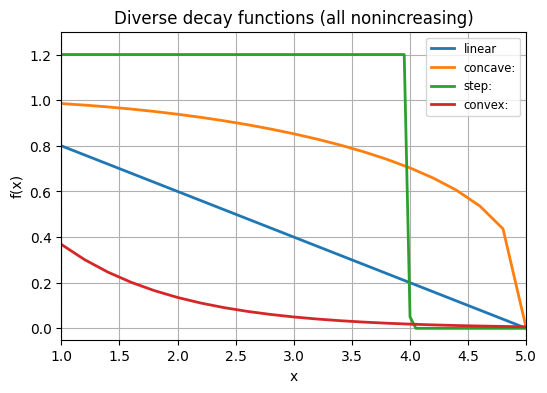

In [11]:
functions = {
    "linear": lambda x: 1 - x/5.0,
    "concave": lambda x: np.cos(np.pi * x / 10)**0.3,
    "step": lambda x: np.where(x < 4, 1.2, np.where(np.isclose(x, 4), 0.05, 0.0)),
    "convex": lambda x: np.exp(-1 * x)}

x = np.arange(1, 6, 0.2)
z = np.arange(1, 6, 0.05)
f_linear = functions["linear"](x)
f_concave = functions["concave"](x)
f_step = functions["step"](z)
f_steep = functions["convex"](x)

# print('f_linear', f_linear)
# print('concave', np.round(f_concave, 3))
# print('f_step', np.round(f_step, 3))
# print('convex', np.round(f_steep, 3))


# Plot everything
plt.figure(figsize=(6, 4))
plt.plot(x, f_linear, label='linear', linewidth=2)
plt.plot(x, f_concave, label='concave:', linewidth=2)
plt.plot(z, f_step, label='step:', linewidth=2)
plt.plot(x, f_steep, label='convex:', linewidth=2)

plt.axvline(1.0, linestyle='--', linewidth=0.8, color='gray')
# plt.text(1.02, 0.95, 'x=1', verticalalignment='center')

plt.title('Diverse decay functions (all nonincreasing)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-0.05, 1.3)
plt.xlim(1, 5)
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.show()

convex
age 0.2498


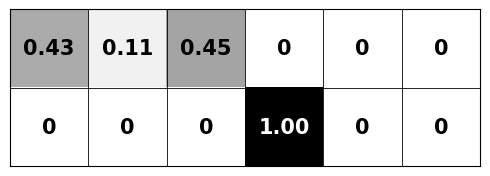

step
age 0.7115


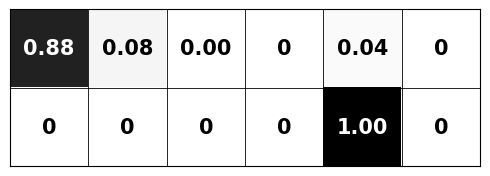

concave
age 1.2998


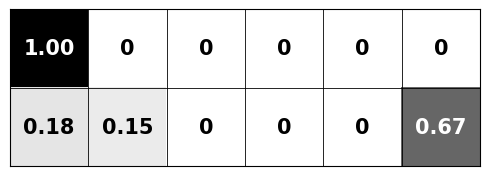

linear
age 0.8531


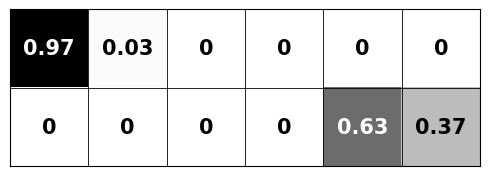

In [12]:
functions_list = [functions["convex"], functions["step"], functions["concave"], functions["linear"]]
fun_name = ['convex', 'step', 'concave', 'linear']
for f1 in range(4):
    H = [0.1, 1]
    hp = [0.5, 0.5]
    W = [0, 1, 2, 3, 4, 5]
    def cal_pow(R, h):
        pow = (2**(R) - 1)/h
        return pow
    P_bar = 10
    D_bar = 0.07
    pkt_prob = 0.9
    mu = cp.Variable((len(H), len(W)), nonneg=True)
    p  = 0
    for k in range(len(H)):
        for j in range(len(W)):
            if W[j] != 0:
                p+= mu[k][j] * hp[k]
    P_u = 0
    for k in range(len(H)):
        for j in range(len(W)):
            P_u+= cal_pow(W[j], H[k]) * mu[k][j] *  hp[k]
    D_u = 0
    for k in range(len(H)):
        for j in range( len(W)):
            bit = W[j]
            fun = functions_list[f1]
            D_u+= (fun(bit) * mu[k][j] *  hp[k] * int(bit > 0))
    obj_fun = pkt_prob * (cp.inv_pos(p) - 1)
    objective = cp.Minimize(obj_fun)
    constraints = []
    val1 = pkt_prob * (1- p)+ p
    constraints.append(P_u*pkt_prob <= P_bar*val1 )
    constraints.append(D_u*pkt_prob <= D_bar * val1)
    a_val = []
    for q in range(len(H)):
        a_val.append( cp.sum([ mu[q][j] for j in range(len(W))]))
    for a in a_val:
        constraints.append(a == 1)
    for i in range(len(H)):           
        for j in range(len(W)):
            constraints.append(0<= mu[i][j])
            constraints.append(mu[i][j] <= 1)
    prob = cp.Problem(objective, constraints)
    prob.solve()
    print(fun_name[f1])
    print('age', np.round(prob.value, 4))
    # print('mu opt\n', np.round(mu.value, 3))
    # print('Pow:', np.round(P_u.value*pkt_prob/(pkt_prob * (1- p.value)+ p.value), 3))
    # print('Dist:', np.round(D_u.value*pkt_prob/(pkt_prob * (1- p.value)+ p.value), 3))
    # print('p:', np.round(p.value, 3))

    mu_opt = mu.value  # assuming this is a 2D numpy array
    rows, cols = mu_opt.shape

    fig, ax = plt.subplots(figsize=(5, 2))

    im = ax.imshow(mu_opt, cmap='Greys', aspect=1)
    # plt.colorbar(im, ax=ax)

    ax.set_yticks([0.1, 1])
    ax.set_yticklabels([r"$h=0.1$", r"$h=1$"])

    ax.set_xticks([])      # removes y-axis tick locations
    ax.set_xlabel("")     # optional: removes y-axis label

    ax.set_yticks([])      # removes y-axis tick locations
    ax.set_ylabel("")     # optional: removes y-axis label



    ax.vlines(np.arange(-0.5, cols, 1), ymin=-0.5, ymax=rows-0.5,
            colors='black', linewidth=0.6)

    # ---- Draw horizontal grid lines ----
    ax.hlines(np.arange(-0.5, rows, 1), xmin=-0.5, xmax=cols-0.5,
            colors='black', linewidth=0.6)


    for i in range(rows):
        for j in range(cols):
            val = mu_opt[i, j]

            label = "0" if np.isclose(val, 0.0) else f"{val:.2f}"

            plt.text(
                j, i,
                label,
                ha="center", va="center",
                color="white" if val > 0.6 else "black",
                fontsize=15,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()


D_bar 0.01
age 0.7771


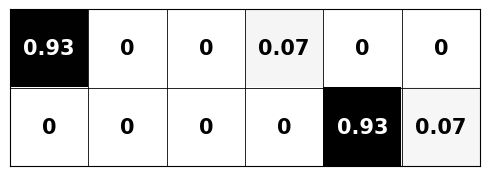

D_bar 0.05
age 0.3353


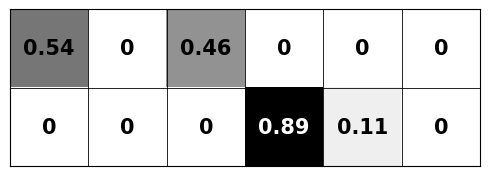

D_bar 0.1
age 0.1544


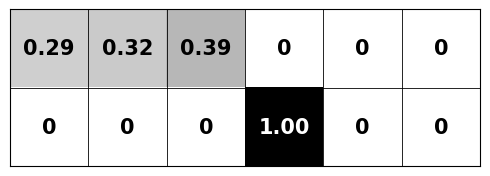

D_bar 0.5
age 0.0


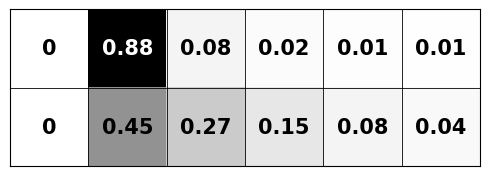

In [4]:
functions_list = [functions["convex"], functions["step"], functions["concave"], functions["linear"]]
# fun_name = ['convex', 'step', 'concave', 'linear']

d_arr = [0.01, 0.05, 0.1, 0.5]
for d_bar in d_arr:
    H = [0.1, 1]
    hp = [0.5, 0.5]
    W = [0, 1, 2, 3, 4, 5]
    def cal_pow(R, h):
        pow = (2**(R) - 1)/h
        return pow
    P_bar = 10
    D_bar = d_bar
    pkt_prob = 0.9
    mu = cp.Variable((len(H), len(W)), nonneg=True)
    p  = 0
    for k in range(len(H)):
        for j in range(len(W)):
            if W[j] != 0:
                p+= mu[k][j] * hp[k]
    P_u = 0
    for k in range(len(H)):
        for j in range(len(W)):
            P_u+= cal_pow(W[j], H[k]) * mu[k][j] *  hp[k]
    D_u = 0
    for k in range(len(H)):
        for j in range( len(W)):
            bit = W[j]
            fun = functions_list[0]
            D_u+= (fun(bit) * mu[k][j] *  hp[k] * int(bit > 0))
    obj_fun = pkt_prob * (cp.inv_pos(p) - 1)
    objective = cp.Minimize(obj_fun)
    constraints = []
    val1 = pkt_prob * (1- p)+ p
    constraints.append(P_u*pkt_prob <= P_bar*val1 )
    constraints.append(D_u*pkt_prob <= D_bar * val1)
    a_val = []
    for q in range(len(H)):
        a_val.append( cp.sum([ mu[q][j] for j in range(len(W))]))
    for a in a_val:
        constraints.append(a == 1)
    for i in range(len(H)):           
        for j in range(len(W)):
            constraints.append(0<= mu[i][j])
            constraints.append(mu[i][j] <= 1)
    prob = cp.Problem(objective, constraints)
    prob.solve()
    print('D_bar', d_bar)
    print('age', np.round(prob.value, 4))
    # print('mu opt\n', np.round(mu.value, 3))
    # print('Pow:', np.round(P_u.value*pkt_prob/(pkt_prob * (1- p.value)+ p.value), 3))
    # print('Dist:', np.round(D_u.value*pkt_prob/(pkt_prob * (1- p.value)+ p.value), 3))
    # print('p:', np.round(p.value, 3))

    mu_opt = mu.value  # assuming this is a 2D numpy array
    rows, cols = mu_opt.shape

    fig, ax = plt.subplots(figsize=(5, 2))

    im = ax.imshow(mu_opt, cmap='Greys', aspect=1)
    # plt.colorbar(im, ax=ax, label='Value')

    ax.set_xticks([])      # removes y-axis tick locations
    ax.set_xlabel("")     # optional: removes y-axis label

    ax.set_yticks([])      # removes y-axis tick locations
    ax.set_ylabel("")     # optional: removes y-axis label

    ax.vlines(np.arange(-0.5, cols, 1), ymin=-0.5, ymax=rows-0.5,
            colors='black', linewidth=0.6)

    # ---- Draw horizontal grid lines ----
    ax.hlines(np.arange(-0.5, rows, 1), xmin=-0.5, xmax=cols-0.5,
            colors='black', linewidth=0.6)

    for i in range(rows):
        for j in range(cols):
            val = mu_opt[i, j]

            label = "0" if np.isclose(val, 0.0) else f"{val:.2f}"

            plt.text(
                j, i,
                label,
                ha="center", va="center",
                color="white" if val > 0.6 else "black",
                fontsize=15,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()


# Prob vs D bar

In [5]:
import matplotlib.pyplot as plt

In [6]:
functions = {
    "linear": lambda x: 1 - x/4.0,
    "concave": lambda x: np.cos(np.pi * x / 8)**0.5,
    "step": lambda x: np.where(x < 2, 1.0, 0.2),
    "convex": lambda x: np.exp(-1.2 * x),
}

0.04


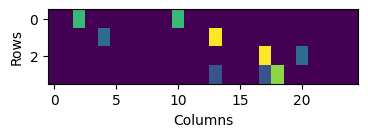

0.08


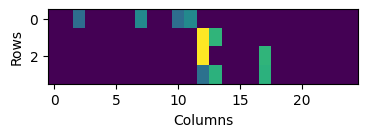

0.1


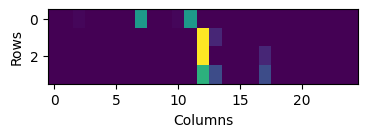

0.2


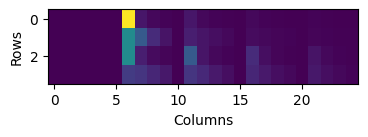

0.5


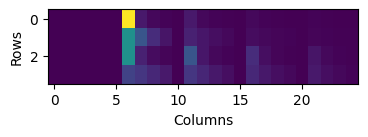

1


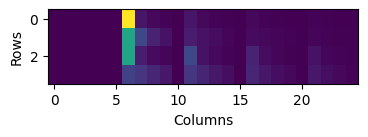

In [7]:
d_arr = [0.04,  0.08, 0.1, 0.2, 0.5, 1]
for D_bar in d_arr:
# p_arr = np.arange(1, 20, 2) 
# for P_bar in p_arr:
    print(D_bar)                            
    n_user = 2
    h_bad =  0.1
    h_good = 1
    pr_h_bad = 0.5
    pr_h_good = (1- pr_h_bad)
    r_max = 4
    rho = np.arange(0, r_max+1, 1)
    h_vec_u1 = np.array([h_bad,  h_good]).tolist()
    permutations_list = []
    permutations_list.extend(list(product(h_vec_u1, repeat=n_user )))
    combined_h_vec = []
    for permutation in permutations_list:
        arr = []
        for k in permutation:
            arr.append(k)
        combined_h_vec.append(arr)
    p_h_u1 = np.array([pr_h_bad, pr_h_good])
    permutations_list = []
    permutations_list.extend(list(product(p_h_u1, repeat=n_user )))
    pr_h = []
    for permutation in permutations_list:
        arr = []
        for k in permutation:
            arr.append(k)
        pr_h.append(np.prod(arr))
    hp = pr_h
    h = combined_h_vec
    W = list(product(rho, repeat=n_user))
    rho_DO = []
    poss_dec_ord = [(1, 2), (2, 1)]
    for w in W:
        for DO in poss_dec_ord:
            rho_DO.append([w, DO])
    def cal_pow(R, DO, h_val):
        sorted_list = DO
        pow_vals = np.zeros(len(DO))
        for i in range(len(DO)):
            idx = DO[i]-1
            sum_i_M = np.sum([R[DO[k]-1]  for k in range(i, len(DO))])
            sum_ip1_M = np.sum([R[DO[k]-1] for k in range(min(i+1, len(DO)), len(DO))])
            pow = (2**(sum_i_M) - 2**(sum_ip1_M))/h_val[idx]
            pow_vals[idx] = pow
        return pow_vals
    P_bar = 20
    l = 0.9
    # D_bar = 0.05
    D_bar_U = n_user*[D_bar]
    pkt_prob = n_user*[l]
    weights = n_user*[1/n_user]
    P_bar_U = n_user*[P_bar]
    mu = cp.Variable((len(h), len(rho_DO) ), nonneg=True)
    p = []
    for x in range(n_user):
        temp  = 0
        for k in range(len(h)):
            for j in range(len(rho_DO)):
                if rho_DO[j][0][x] != 0:
                    temp+= mu[k][j] * hp[k]
        p.append(temp)
    P_u = []
    for x in range(n_user):
        temp = 0
        for k in range(len(h)):
            for j in range( len(rho_DO)):
                temp+= cal_pow(rho_DO[j][0], rho_DO[j][1] , h[k])[x] * mu[k][j] *  hp[k]
        P_u.append(temp)
    D_u = []
    for x in range(n_user):
        temp = 0
        for k in range(len(h)):
            for j in range( len(rho_DO)):
                bit = rho_DO[j][0][x]
                fun = functions["convex"]
                temp+= (fun(bit) * mu[k][j] *  hp[k] * int(bit > 0))
        D_u.append(temp)
    obj_fun = 0
    for n in range(n_user):
        obj_fun = obj_fun + ( weights[n] *  pkt_prob[n] * (cp.inv_pos(p[n])  -  1 )  )
    objective = cp.Minimize(obj_fun)
    constraints = []
    for n in range(n_user):
        val1 = pkt_prob[n] * (1- p[n])+ p[n]
        constraints.append(P_u[n]*pkt_prob[n] <= P_bar_U[n]*val1 )
        constraints.append(D_u[n]*pkt_prob[n] <= D_bar_U[n] * val1)
    a_val = []
    for q in range(len(h)):
        a_val.append( cp.sum([ mu[q][j] for j in range(len(rho_DO))]))
    for a in a_val:
        constraints.append(a == 1)
    for i in range(len(h)):           
        for j in range(len(rho_DO)):
            constraints.append(0<= mu[i][j])
            constraints.append(mu[i][j] <= 1)
    prob = cp.Problem(objective, constraints)
    prob.solve()
    # print('age', np.round(prob.value, 4))
    mu_opt = mu.value
    mu_mld = mu_opt.reshape(4, 25, 2).sum(axis=2)
    plt.figure(figsize=(4, 2))
    plt.imshow(mu_mld, cmap='viridis', aspect=1.5)
    # plt.colorbar(label='Value')
    # plt.title(name)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()

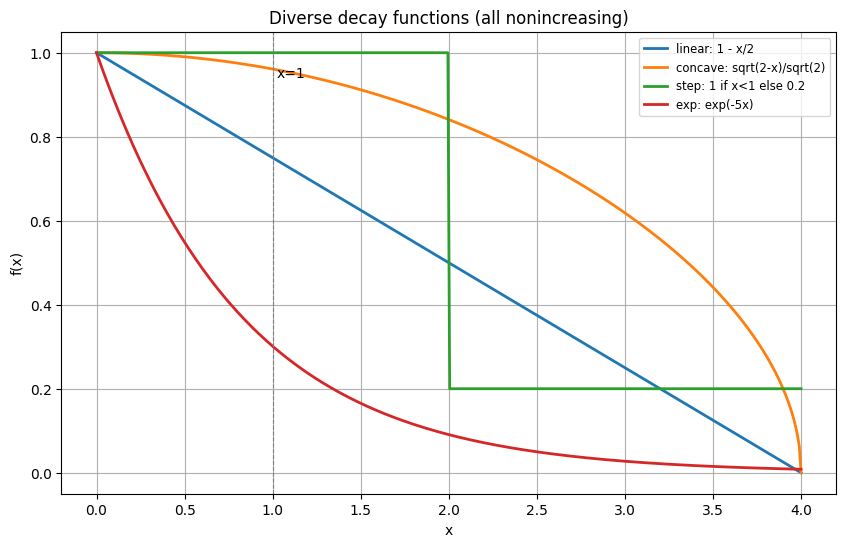

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# x-range
x = np.linspace(0, 4, 400)


# 2) Linear: straight line from 1 at x=0 to 0 at x=2
f_linear = 1 - x/4.0
# 3) Concave: sqrt shape normalized so f(0)=1, f(2)=0
f_concave = np.cos(np.pi * x / 8)**0.5
# 4) Step (exactly as you specified)
#    f(x) = 1 if x < 1, else 0.2
f_step = np.where(x < 2.0, 1.0, 0.2)
# 5) Convex
#    This is an exponential with a steep rate so it looks almost like a step near 1
f_steep = np.exp(-1.2 * x)   # f(0)=1, f(2)=exp(-10) ~ 4.5e-5

# Make sure all plotted values are within [0,1] (they already are, but clip for safety)
f_linear = np.clip(f_linear, 0, 1)
f_concave = np.clip(f_concave, 0, 1)
f_step = np.clip(f_step, 0, 1)
f_steep = np.clip(f_steep, 0, 1)

# Plot everything
plt.figure(figsize=(10, 6))
plt.plot(x, f_linear, label='linear: 1 - x/2', linewidth=2)
plt.plot(x, f_concave, label='concave: sqrt(2-x)/sqrt(2)', linewidth=2)
plt.plot(x, f_step, label='step: 1 if x<1 else 0.2', linewidth=2)
plt.plot(x, f_steep, label='exp: exp(-5x)', linewidth=2)

plt.axvline(1.0, linestyle='--', linewidth=0.8, color='gray')
plt.text(1.02, 0.95, 'x=1', verticalalignment='center')

plt.title('Diverse decay functions (all nonincreasing)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.show()
